In [2]:
import Pkg
Pkg.add("Kinbiont")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("Plots")
Pkg.add("Statistics")
Pkg.add("DecisionTree")
Pkg.add("AbstractTrees")
Pkg.add("MLJDecisionTreeInterface")
Pkg.add("TreeRecipe")
Pkg.add("Random")

using Kinbiont, CSV, DataFrames, Plots, Statistics, DecisionTree, AbstractTrees
using MLJDecisionTreeInterface, TreeRecipe, Random


   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks

Data from ["Construction and Modeling of a Coculture Microplate for Real-Time Measurement of Microbial Interactions"](https://journals.asm.org/doi/10.1128/msystems.00017-21).

We consider the data for the Coculture of Gut drosphila microbiome. We obtained the annotation from the code of the github of the paper.

In [56]:

# load data
data = CSV.read("../CoCultures_ODEs_system/data/DATA_Gut_Microbiome_CoC.csv", DataFrame);
# convert time column from in elapsed time from the start in hours, the delta time in the data is 15 minutes

delta_time = 15/60;
time_seq = 0:delta_time:(size(data,1)-1)*delta_time;
time_seq = [ time_seq[i] for i in 1: length(time_seq)];
data[!,:Time] = time_seq ;

We initialize the model the parameter guess and the vector where store the results.

In [57]:
model ="aHPM";
results_matrix = Kinbiont.initialize_df_results(model);

p_guess = [0.2, 0.001, 1.00, 1.0];
ub_ahpm = [3.0, 1.0,3.00, 5.0];
lb_ahpm = [0.001, 0.0,0.2, 0.0];

We start fitting the data of Acetobacter Oryzifermentans (AO). We consider the wells where is present such bacteria and in the connected wells there is only media. We make the average of the replicates and fit them.

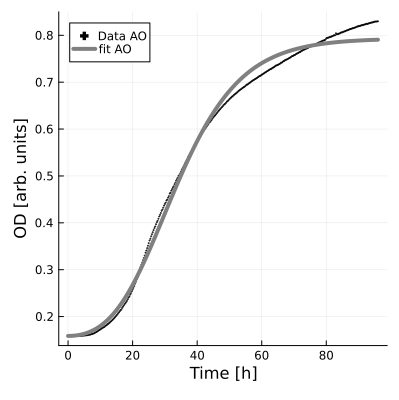

In [58]:
# Fitting all AO data
# Not interacting A0
# AO, -
# [1,21,41];
A0 = [1,21,41].+1;

data_A0 = data[:,A0] ;#.- blanS1_value

# mean of the replicates
data_A0_mean = mean(Matrix(data_A0),dims=2);

# Formatting data for Kinbiont
data_to_fit = permutedims( [time_seq data_A0_mean]);

# Performing ODE fitting
results_ODE_fit = Kinbiont.fitting_one_well_ODE_constrained(
    data_to_fit, 
    "AO_NA",
    "CoC_DT",
    model,
    p_guess;
    lb = lb_ahpm,
    ub = ub_ahpm,
);
Plots.scatter(data_to_fit[1,:],data_to_fit[2,:], xlabel="Time [h]", ylabel="OD [arb. units]", label=["Data AO" nothing],color=:black,markersize =1,marker=:cross ,size = (400,400))
display(Plots.plot!(results_ODE_fit[4],results_ODE_fit[3], xlabel="Time [h]", ylabel="OD [arb. units]",label=["fit AO" nothing],color=:grey,markersize =4 ,size = (400,400),linewidth=4))
results_matrix = [results_matrix results_ODE_fit[2]];


In [59]:
results_matrix

10×2 Matrix{Any}:
 "label_exp"       "CoC_DT"
 "well"            "AO_NA"
 "model"           "aHPM"
 "gr"             0.285037
 "exit_lag_rate"  0.0175675
 "N_max"          0.793403
 "shape"          0.308695
 "th_max_gr"      0.04766
 "emp_max_gr"     0.0736753
 "loss"           0.000508775

Now we select the data of AO where in the other wells are present the Lactobacillus Brevis.

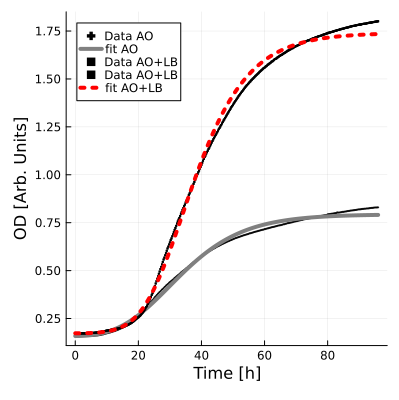

In [61]:
A0 = [13,33,53,17].+1;

data_A0 = data[:,A0] ;#.- blanS1_value

# mean of the replicates
data_A0_mean = mean(Matrix(data_A0),dims=2);

# Formatting data for Kinbiont
data_to_fit = permutedims( [time_seq data_A0_mean]);

# Performing ODE fitting
results_ODE_fit = Kinbiont.fitting_one_well_ODE_constrained(
    data_to_fit, 
    "AO_LB",
    "CoC_DT",
    model,
    p_guess;
    lb = lb_ahpm,
    ub = ub_ahpm,
);
Plots.scatter!(data_to_fit[1,:],data_to_fit[2,:], xlabel="Time [h]", ylabel="OD [Arb. Units]", label=["Data AO+LB" nothing],color=:black,markersize =1,marker=:square ,size = (400,400))
display(Plots.plot!(results_ODE_fit[4],results_ODE_fit[3], xlabel="Time [h]", ylabel="OD [Arb. Units]",label=["fit AO+LB" nothing],color=:red,markersize =4 ,size = (400,400),linewidth=4,linestyle=:dot))


# we stack the results on the created matrix
results_matrix = hcat(results_matrix, results_ODE_fit[2]);


In [62]:
results_matrix

10×3 Matrix{Any}:
 "label_exp"       "CoC_DT"     "CoC_DT"
 "well"            "AO_NA"      "AO_LB"
 "model"           "aHPM"       "aHPM"
 "gr"             0.285037     2.5311
 "exit_lag_rate"  0.0175675    0.00222462
 "N_max"          0.793403     1.74019
 "shape"          0.308695     0.0387696
 "th_max_gr"      0.04766      0.0828456
 "emp_max_gr"     0.0736753    0.120278
 "loss"           0.000508775  0.000482416

We select the wells where AO interacts with L. Plantarum.

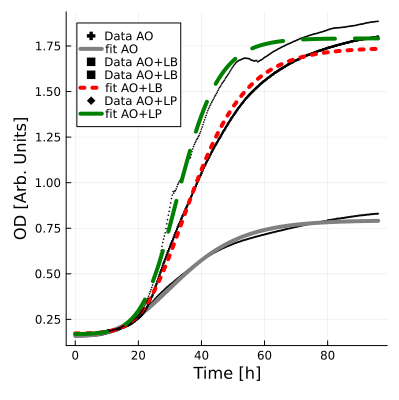

In [63]:
A0 =  [11,31,51,7].+1;

data_A0 = data[:,A0]; #.- blanS1_value

# mean of the replicates
data_A0_mean = mean(Matrix(data_A0),dims=2);

# Formatting data for Kinbiont
data_to_fit = permutedims( [time_seq data_A0_mean]);

# Performing ODE fitting
results_ODE_fit = Kinbiont.fitting_one_well_ODE_constrained(
    data_to_fit, 
    "AO_LP",
    "CoC_DT",
    model,
    p_guess;
    lb = lb_ahpm,
    ub = ub_ahpm,
);
Plots.scatter!(data_to_fit[1,:],data_to_fit[2,:], xlabel="Time [h]", ylabel="OD [Arb. Units]", label=["Data AO+LP" nothing],color=:black,markersize =1,marker=:diamond ,size = (400,400))
display(Plots.plot!(results_ODE_fit[4],results_ODE_fit[3], xlabel="Time [h]", ylabel="OD [Arb. Units]",label=["fit AO+LP" nothing],color=:green,markersize =4 ,size = (400,400),linewidth=4,linestyle=:dash))


# we stack the results on the created matrix
results_matrix = hcat(results_matrix, results_ODE_fit[2]);


In [64]:
results_matrix

10×4 Matrix{Any}:
 "label_exp"       "CoC_DT"     "CoC_DT"     "CoC_DT"
 "well"            "AO_NA"      "AO_LB"      "AO_LP"
 "model"           "aHPM"       "aHPM"       "aHPM"
 "gr"             0.285037     2.5311       0.31993
 "exit_lag_rate"  0.0175675    0.00222462   0.00276445
 "N_max"          0.793403     1.74019      1.7916
 "shape"          0.308695     0.0387696    0.474521
 "th_max_gr"      0.04766      0.0828456    0.0995082
 "emp_max_gr"     0.0736753    0.120278     0.136531
 "loss"           0.000508775  0.000482416  0.000883694

Finally the wells where are both present AO.

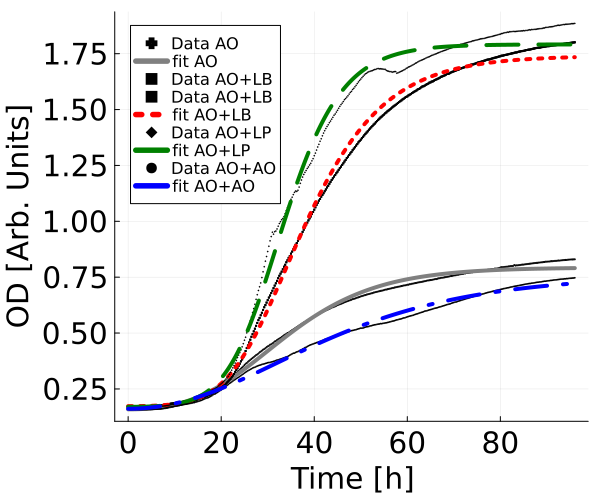

In [65]:

# AO, AO
# [37,47,57];



A0 =[37,47,57].+1;

data_A0 = data[:,A0] ;#.- blanS1_value

# mean of the replicates
data_A0_mean = mean(Matrix(data_A0),dims=2);

# Formatting data for Kinbiont
data_to_fit = permutedims( [time_seq data_A0_mean]);

# Performing ODE fitting
results_ODE_fit = Kinbiont.fitting_one_well_ODE_constrained(
    data_to_fit, 
    "AO_AO",
    "CoC_DT",
    model,
    p_guess;
    lb = lb_ahpm,
    ub = ub_ahpm,
);
Plots.scatter!(data_to_fit[1,:],data_to_fit[2,:], xlabel="Time [h]", ylabel="OD [Arb. Units]", label=["Data AO+AO" nothing],color=:black,markersize =1 ,size = (300,300))
display(Plots.plot!(results_ODE_fit[4],results_ODE_fit[3], xlabel="Time [h]", ylabel="OD [Arb. Units]",label=["fit AO+AO" nothing],color=:blue,markersize =4 ,size = (600,500),legendposition = :topleft,linewidth=4,linestyle=:dashdot,tickfontsize = 20,labelfontsize = 20,legendfontsize =11))

results_matrix = hcat(results_matrix, results_ODE_fit[2]);


We stored the results in a matrix with this format ready for the next passage. 

In [66]:
results_matrix

10×5 Matrix{Any}:
 "label_exp"       "CoC_DT"     "CoC_DT"     "CoC_DT"     "CoC_DT"
 "well"            "AO_NA"      "AO_LB"      "AO_LP"      "AO_AO"
 "model"           "aHPM"       "aHPM"       "aHPM"       "aHPM"
 "gr"             0.285037     2.5311       0.31993      0.706796
 "exit_lag_rate"  0.0175675    0.00222462   0.00276445   0.0436636
 "N_max"          0.793403     1.74019      1.7916       0.760342
 "shape"          0.308695     0.0387696    0.474521     0.0608487
 "th_max_gr"      0.04766      0.0828456    0.0995082    0.0336464
 "emp_max_gr"     0.0736753    0.120278     0.136531     0.0633558
 "loss"           0.000508775  0.000482416  0.000883694  0.000932664

We create a feature matrix. For each curve, we annotate which strain was present in the other well with 1 present 0 not present. Note that the second row (well) of the results matrix has a label that matches the first column of the feature matrix. The order does not matter; only where a match is valid will these samples be used for inference.

In [71]:
# Creating feature Matrix
label_row = ["AO_NA","AO_LB","AO_LP","AO_AO"];
starting_0 = zeros(Int,4,3);
feature_matrix = hcat(label_row,starting_0);
feature_matrix[2,2] = 1 ;
feature_matrix[3,3] = 1 ;
feature_matrix[4,4] = 1 ;
feature_names = ["LP","LB","AO"];
feature_matrix

4×4 Matrix{Any}:
 "AO_NA"  0  0  0
 "AO_LB"  1  0  0
 "AO_LP"  0  1  0
 "AO_AO"  0  0  1

We set seed and we run a decision tree regression. Note that row to learn is 6. Meaning that we do a regression of the N max (the 6th row in result matrix).
After the regression we plot the tree.

In [72]:
seed= Random.seed!(1234);
dt = Kinbiont.downstream_decision_tree_regression(results_matrix,
        feature_matrix,
        6;  # Row to learn
        do_pruning=false,
        verbose=true,
        do_cross_validation=false,
        max_depth=-1, 
        seed=seed,
        min_samples_leaf =1,
    #    min_purity_increase= 0.001, 
        min_samples_split=2
    )


Feature 2 < 0.5 ?
├─ Feature 1 < 0.5 ?
    ├─ Feature 3 < 0.5 ?
        ├─ 0.793402978983966 : 1/1
        └─ 0.7603423899831435 : 1/1
    └─ 1.7401859196259244 : 1/1
└─ 1.791596388827591 : 1/1


(Decision Tree
Leaves: 4
Depth:  3, [0.15466206483340966, 0.09020769808282947, 0.00013662531813513068], [1.0, 1.0, 1.0], Any, Any["values" 1.0 … 3.0 4.0; "cluster" 0.793402978983966 … 1.7401859196259244 1.791596388827591])

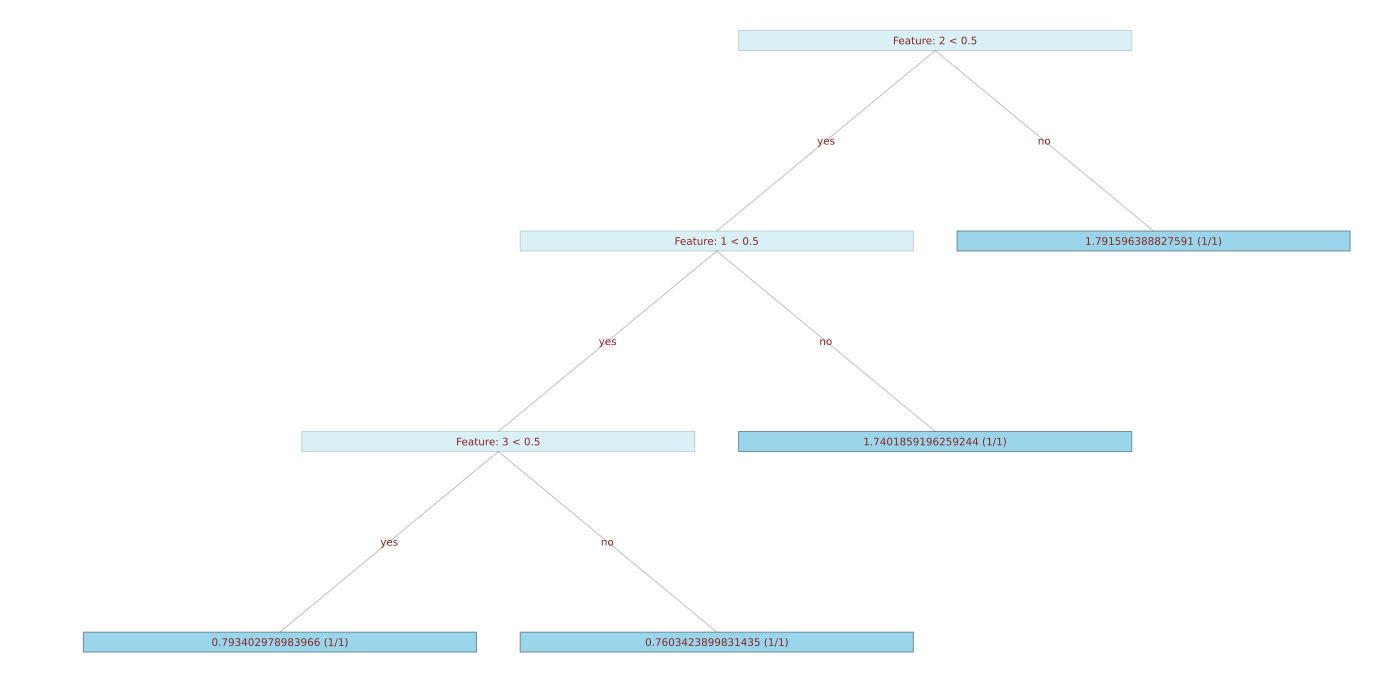

the feature order respect the one in the input feature matrix, i.e.,: LB,LP,AO


In [74]:

# Visualizing the decision tree

wt = DecisionTree.wrap(dt[1]);
p2 = Plots.plot(wt, 0.9, 0.2; size=(1400, 700), connect_labels=["yes", "no"]);
println(string("the feature order respect the one in the input feature matrix, i.e.,: LB,LP,AO"))
display(p2)